# Regresión Lineal
---
#### By: Laurie Camila Hernández Pacheco | A01286569

El dataset elegido para esta actividad es `California Housing Prices`, obtenido de Kaggle (es `housing.csv`). Este dataset tiene información relacionada al censo realizado en California en 1990. Contiene un total de 10 columnas distintas, que se describen a continuación: 

1. `longitude`: la localización del lugar con respecto a la dirección Oeste desde el meridiano de Greenwich. Mayor valor $\rightarrow$ más hacia el oeste.
2. `latitude`: la localización del lugar con respecto a la dirección Norte desde el ecuador. Mayor valor $\rightarrow$ más hacia el norte. 
3. `housing_median_age`: edad mediana de las casas en un bloque. Más bajo $\rightarrow$ más recientes son las construcciones.  
4. `total_rooms`: número de habitaciones dentro de un bloque. 
5. `total_bedrooms`: número de dormitorios dentro de un bloque. 
6. `population`: número de personas que viven en un bloque. 
7. `households`: número de hogares dentro de un bloque. 
8. `median_income`: ingreso mediano de los hogares dentro de un bloque (medido en decenas de miles de dólares estadounidenses).
9. `median_house_value`: valor mediano de las casas dentro de un bloque (medido en dólares estadounidenses).
10. `ocean_proximity`: ubicación de la casa con respecto al óceano o mar. 

Todas estas variables son de tipo punto flotante, a excepción de `ocean_proximity` que se divide en 5 categorías distintas: `['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']`.  

Siguiendo el tutorial recomendado en KD Nuggets se llevará a cabo el problema de regresión. 

## 0. Setup

Inicialmente se importarán las librerías necesarias para la actividad:  
1. `pandas`: para manipulación del dataset. 
2. `numpy`: para cálculos numéricos. 
3. `matplotlib`: para visualización y gráficos. 
4. `seaborn`: para visualización y mapas de calor. 
5. `sklearn`: para implementar el modelo de regresión lineal. 

In [ ]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn import metrics

## 1. Exploración Básica de los Datos

Aquí se importará la tabla `.csv` de los datos, asimismo se obtendrá información importante, como las dimensiones del dataframe con `shape` así como también los detalles estadísticos (para las variables que aplica) con `describe`

In [2]:
df = pd.read_csv('housing.csv')
print("Dimensiones del dataframe: ", df.shape)
print("\nDescripción estadística del dataset")
df.describe()

Dimensiones del dataframe:  (20640, 10)

Descripción estadística del dataset


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Con `shape` se identificaron 20640 filas y 10 columnas distintas dentro del dataframe. Mientras tanto, con `describe` se puede notar que para la mayoría de columnas se contiene la cantidad completa de datos (40640), sin embargo destaca que a la columna `total_bedrooms` le hacen falta 7 filas. Antes de continuar con el tutorial, se limpiarán esas filas vacías. 

In [3]:
df = df.dropna(subset=["total_bedrooms"])
print("\nDescripción estadística del dataset (sin NaNs)")
df.describe()


Descripción estadística del dataset (sin NaNs)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Finalmente, para mantener todos los datos con la misma unidad de medida (específicamente aquellos datos en USD), se multiplicará la columna de `median_income` por $10,000$, puesto que los valores se encuentran en decenas de miles de dólares, mientras que para la columna `median_house_value` se encuentran directamente en dólares. 

In [4]:
df["median_income"] = df["median_income"] * 10000
print("\nDescripción estadística del dataset (sin NaNs y en USD)")
df.describe()


Descripción estadística del dataset (sin NaNs y en USD)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,38711.616013,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,18992.912493,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,4999.000000,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,25637.000000,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,35365.000000,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,47440.000000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,150001.000000,500001.000000


## 2. Visualización de Datos

Para identificar correlación entre las variables, antes de continuar con el tutorial, se realizará una matriz de correlación entre las variables, a partir de las cuales se identificarán dos columnas con las que se llevará a cabo el análisis. Sin embargo, será necesario eliminar la variable categórica puesto que una matriz de correlación no puede llevarse a cabo con valores no numéricos. En otras situaciones o futuras asignaciones, valdría la pena transformarla mediante técnicas como one-hot encoding para poder aprovechar esta información. 

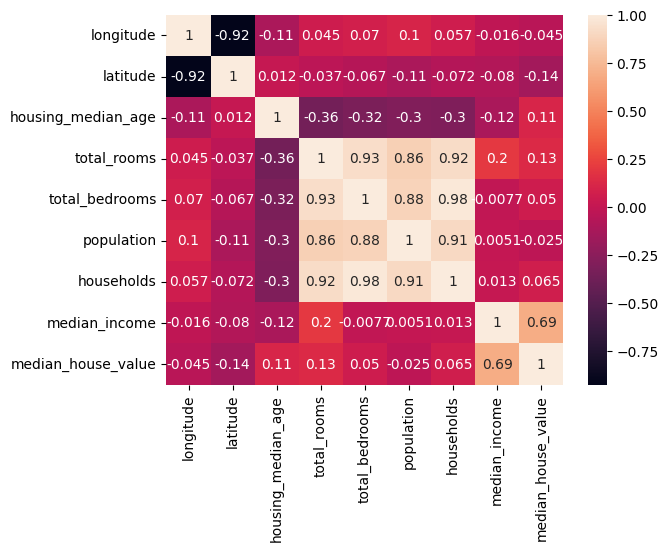

In [5]:
df = df.drop(columns=["ocean_proximity"]) # eliminamos la columna
corr_matrix = df.corr() # obtenemos matriz de correlación y luego la imprimimos. 
plt.figure()
sns.heatmap(corr_matrix, annot=True)
plt.show()

Con base en la matriz de correlación, se identifica que para las variables `total_rooms`, `total_bedrooms`, `population` y `households` existe **multicolinealidad** lo que significa que guardan altas relaciones entre sí, además de que algunas son derivadas de otras: `total_bedrooms` es un subset dentro de `total_rooms` por ejemplo. En este caso, las variables no son completamente *independientes* por decirlo así.  

Se identificó una correlación fuerte entre `median_income` y `median_house_value`, sin estar directamente relacionadas, por lo tanto estas dos features serán las que se utilizarán para continuar con el análisis y el tutorial. Se trabajará con `median_house_value` como la variable independiente mientras que `median_income` será la variable dependiente. Por lo tanto, el modelo de regresión lineal buscara´predecir el ingreso mediano del bloque con base en  el valor mediano de las casas del bloque. 

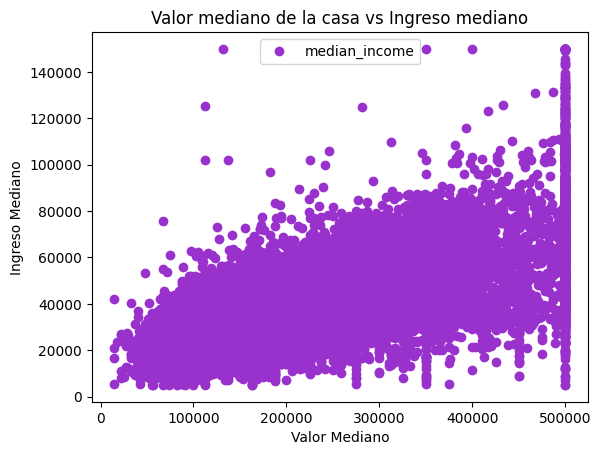

In [6]:
df.plot(x='median_house_value', y='median_income', style='o', color ="darkorchid")  
plt.title('Valor mediano de la casa vs Ingreso mediano')  
plt.xlabel('Valor Mediano')  
plt.ylabel('Ingreso Mediano')  
plt.show()

A continuación, se visualizará el ingreso mediano promedio y su distribución de densidad. 

<Axes: xlabel='median_income', ylabel='Count'>

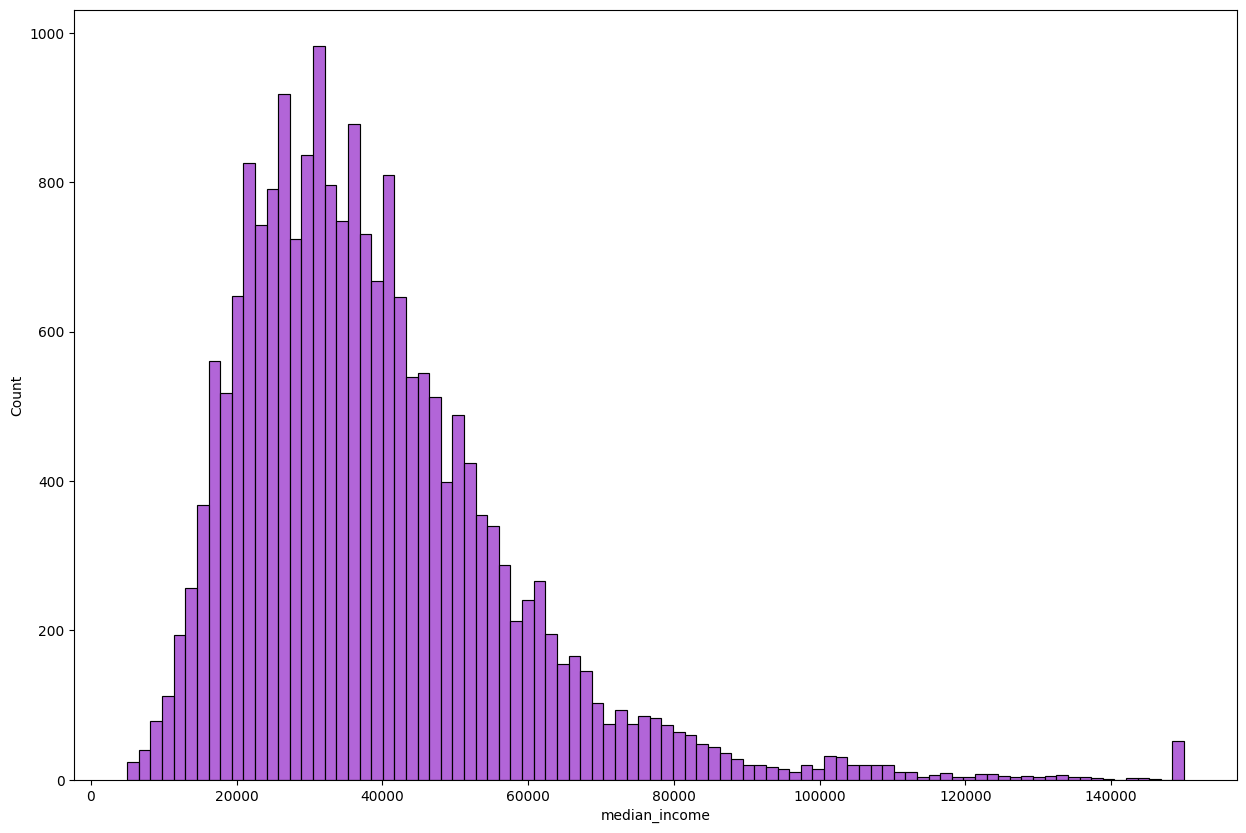

In [7]:
plt.figure(figsize=(15,10))
plt.tight_layout()
sns.histplot(df['median_income'], color = "darkorchid")

Se puede identificar cómo `median_income` se encuentra mayoritariamente en el rango desde los $20,000 USD hasta casi los $50,000 USD. 

## 3. Entrenamiento del Modelo 

Ya elegidas las variables para realizar el modelo, se identificarán entre *atributos* y *etiquetas*. Los atributos se indican que son las variables independientes, mientras que las etiquetas son las variables dependientes. En este caso, el atributo sería `median_house_value` y la etiqueta sería `median_income`. Inicialmente, se convertirán los vectores de datos en matrices 2D para indicar que tenemos únicamente 1 feature. 

In [8]:
X = df['median_house_value'].values.reshape(-1,1)
y = df['median_income'].values.reshape(-1,1)

Posteriormente, realizaremos la división del dataset entre datos de entrenamiento y datos de prueba, manteniendo una división 80/20: 

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

A continuación, se realizará el entrenamiento con el set de entrenamiento. Inicialmente se llamará al regressor `LinearRegression()` de la librería `sklearn` y posteriormente se usará `fit` para entrenar el modelo con los datos.

In [10]:
regressor = LinearRegression()  
regressor.fit(X_train, y_train) 

LinearRegression()

A continuación, se visualizará la intersección y la pendiente calculada por parte del algoritmo de regresión lineal: 

In [11]:
print(f"Intersección: {regressor.intercept_}")
print(f"Pendiente: {regressor.coef_}")

Intersección: [15245.99342802]
Pendiente: [[0.11332723]]


## 4. Resultados del Modelo 

Ya entrenado el algoritmo, es posible visualizar los resultados que se obtienen con él. A continuación, se realizarán las predicciones con los datos de prueba y se visualizarán con respecto a los datos reales de prueba. 

In [12]:
y_pred = regressor.predict(X_test)
df1 = pd.DataFrame({'Actual': y_test.flatten(), 'Predicted': y_pred.flatten()})
df1

,Actual,Predicted
0,28750.0,26454.056956
1,35250.0,32585.060362
2,13448.0,25592.769971
3,72758.0,54366.554902
4,64631.0,54241.894944
...,...,...
4082,26523.0,23892.861448
4083,43882.0,44892.398068
4084,24122.0,29638.552255
4085,31641.0,33219.692877


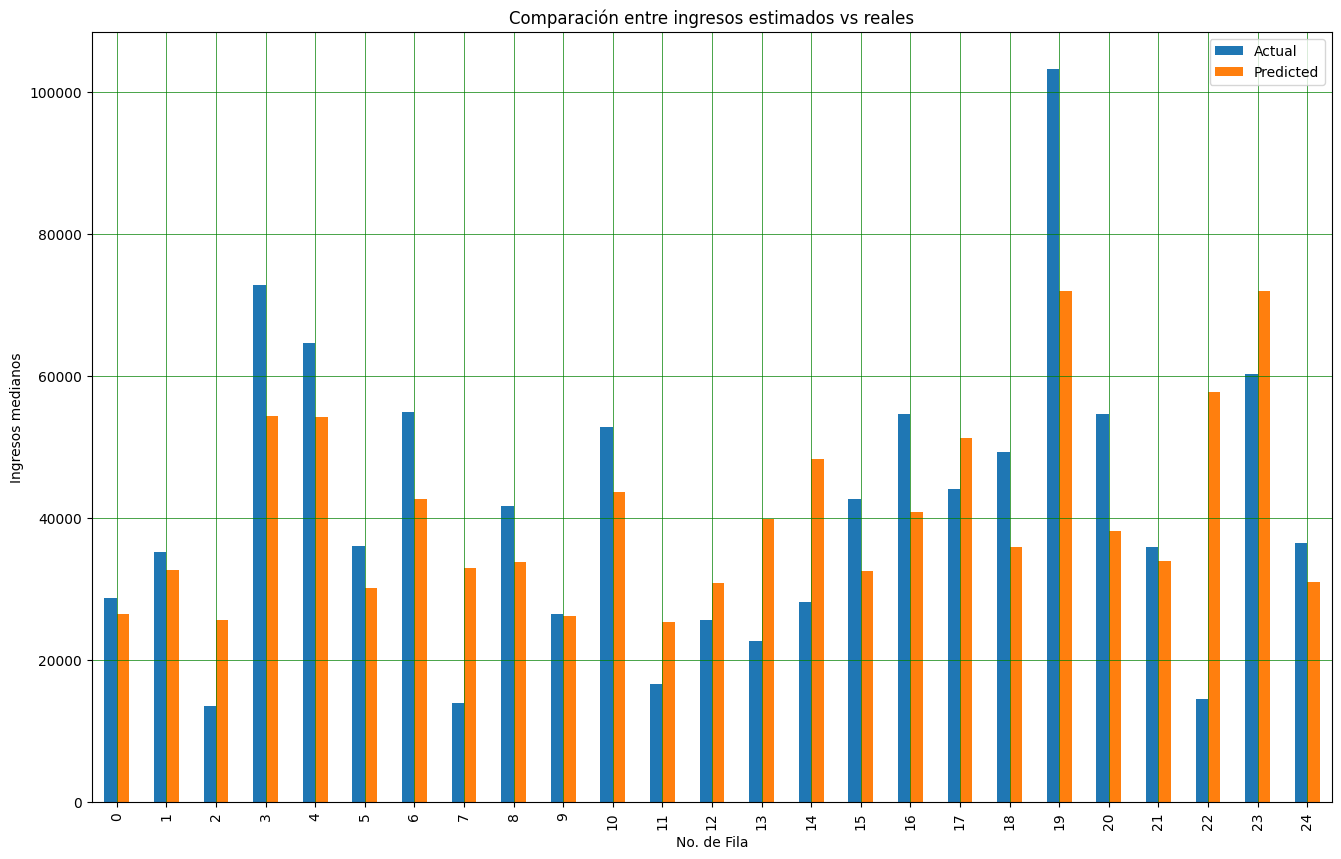

In [13]:
df2 = df1.head(25)
df2.plot(kind='bar',figsize=(16,10))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
plt.title("Comparación entre ingresos estimados vs reales")
plt.ylabel("Ingresos medianos")
plt.xlabel("No. de Fila")
plt.show()

Se puede visualizar cómo a veces la predicción sobreestima o subestima el ingreso mediano real, pero se mantiene dentro de un rango muy similar al valor actual. A continuación se graficarán los datos de prueba y la recta del predicciones. 

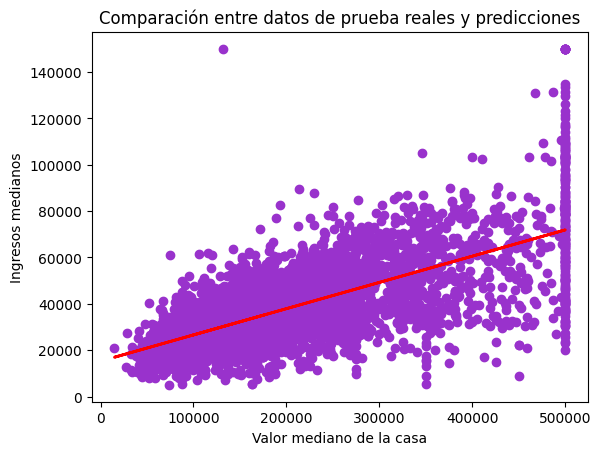

In [14]:
plt.scatter(X_test, y_test,  color='darkorchid')
plt.plot(X_test, y_pred, color='red', linewidth=2)
plt.title("Comparación entre datos de prueba reales y predicciones")
plt.xlabel("Valor mediano de la casa")
plt.ylabel("Ingresos medianos")
plt.show()

Se puede visualizar cómo la línea roja que corresponde al modelo de regresión lineal guarda una relación relevante con los datos de prueba reales: el ingreso mediano aumenta con respecto a como los datos se comportan, y si bien la discrepancia puede ser elevada en algunos casos, cubre un gran porcentaje de la relación entre los datos. 

## 5. Evaluación del Modelo 

Finalmente, es necesario evaluar el modelo y con métricas de evaluación: 
1. Mean Absolute Error (MAE): el promedio del valor absoluto de los errores, se calcula: 
$$ 
MAE = \frac{1}{n} \sum _{j=1}^n |y_j -\hat{y_j }|
$$
2. Mean Squared Error (MSE): el promedio de los errores al cuadrado, se calcula: 
$$ 
MSE = \frac{1}{n} \sum _{i=1}^n (y_i -\hat{y_i})^2
$$
3. Root Mean Squared Error (RMSE): la raíz cuadrada del promedio de los errores al cuadrado, se calcula: 
$$ 
MSE = \sqrt{\frac{1}{n} \sum _{i=1}^n (y_i -\hat{y_i})^2}
$$

Existen funciones ya predeterminadas en `sklearn` para calcularlos, en vez de cargar todo de manera manual. A continuación se muestran las tres métricas para los datos. 

In [15]:
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error: 10093.578499812447
Mean Squared Error: 186892502.5899673
Root Mean Squared Error: 13670.863271570208


## 6. Reflexión

A lo largo del tutorial, tuve un poco de complicación para seguirlo, principalmente por mi elección de dataset, pues tiene más de 2 columnas. Sin embargo, debido a experiencia previa con este tipo de proyectos, no tuve tanta dificultad para realizar la selección de features para el modelo, así continuando el proceso de seguir el tutorial. Una situación interesante que me ocurrió fue que si bien noté que mis dos variables seleccionadas estaban en ordenes de magnitud distintos, no pensé en cambiarlas hasta que obtuve los resultados de la pendiente y la intersección de la recta. Sin embargo, no hubo mayor dificultad para realizar esa modificación más que multiplicar la columna de `median_income`. 

El modelo en general presenta un error de aproximadamente $10,000 USD con respecto a los valores reales. Con base en la sección de resultados, noté que para valores medios tiene una mayor cercanía al valor real (como por ejemplo, aquellos valores de entre $20,000 y $45,000 USD). Sin embargo, para valores más extremos tiende a sobreestimar (si el valor es muy pequeño) o subestimar (si el valor es muy elevado). Esto también se refleja en el RMSE que es aproximadamente 3,000 mayor que el MAE. Esto puede ser común en regresión lineal debido a que la recta busca capturar las similitudes entre la mayoría de los datos. 